<a href="https://colab.research.google.com/github/vannsoko/MNIST/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install --upgrade optuna

In [ ]:
import optuna
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL Image to tensor (C x H x W)
])

# Load the MNIST dataset
dataset = datasets.MNIST(
    root='./data',          # Directory to store the dataset
    train=True,             # Load the training set
    download=True,          # Download if not available
    transform=transform,    # Apply the transform
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform,
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 64

val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)



lr=0.001 => loss=1.4612 ep=7 : 97.6%

[I 2025-10-07 19:00:52,894] Trial 49 finished with value: 1.4865225198421073 and parameters: {'lr': 0.0002896285253050259, 'batch_size': 16, 'hidden_size1': 641, 'hidden_size2': 403, 'dropout': 0.21759572322363618}. Best is trial 31 with value: 1.4832874181422782.
Test Loss: 1.481069841980934; Test accuracy: 97.94
Best params: {'lr': 0.0002154130042128118, 'batch_size': 32, 'hidden_size1': 822, 'hidden_size2': 804, 'dropout': 0.11041526551552969}
Best value: 1.4832874181422782

In [ ]:
class MNIST(nn.Module):
  def __init__(self, h1, h2, dropout):
    super(MNIST, self).__init__()
    self.flatten = nn.Flatten()
    self.linear_rellu_stack = nn.Sequential(
        nn.Linear(28*28, h1),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(h2, 10),
    )
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_rellu_stack(x)
    return self.softmax(logits)

In [ ]:
def train_epoch(model, optimizer, batch_size):
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  criterion = nn.CrossEntropyLoss()
  model.train()
  for images, labels in train_loader:
    # Move tensors to the configured device
    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward pass and optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(f"Loss: {loss.item():.4f}")
  return loss.item()

def validate(model, dataset, batch_size):
  model.eval()
  criterion = nn.CrossEntropyLoss()
  total_loss = 0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in dataset:
      # Move tensors to the configured device
      images = images.to(device)
      labels = labels.to(device)

      # Forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)
      total_loss += loss.item()

      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  avg_loss = total_loss / len(dataset)
  accuracy = 100 * correct / total
  return avg_loss, accuracy

In [ ]:
def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    hidden_size1 = trial.suggest_int('hidden_size1', 256, 2056)
    hidden_size2 = trial.suggest_int('hidden_size2', 128, 2056)

    dropout = trial.suggest_float('dropout', 0.05, 0.25)
    #n_layers = trial.suggest_int('n_layers', 1, 4)

    # Build model
    model = MNIST(h1=hidden_size1,
                      h2=hidden_size2,
                      dropout=dropout,
                      ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train
    for epoch in tqdm(range(40)):
        train_loss = train_epoch(model, optimizer, batch_size)
        val_loss, val_accuracy = validate(model, val_loader, batch_size)
        test_loss, test_accuracy = validate(model, test_loader, batch_size)

        print(f"Test Loss: {test_loss}; Test accuracy: {test_accuracy}")
        trial.set_user_attr('test_loss', test_loss)
        trial.set_user_attr('test_accuracy', test_accuracy)
        trial.set_user_attr('final_train_loss', train_loss)
        # Report intermediate value for pruning
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()



    return test_accuracy

In [ ]:
# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Best params: {study.best_params}")
print(f"Best value: {study.best_value}")

[I 2025-10-07 21:57:04,371] A new study created in memory with name: no-name-b79dc46c-b5f7-4df9-9104-5150a06c9db6
  0%|          | 0/40 [00:00<?, ?it/s]

Loss: 1.5858


  2%|▎         | 1/40 [00:41<27:08, 41.77s/it]

Test Loss: 1.5272020041942596; Test accuracy: 93.35
Loss: 1.5850


  5%|▌         | 2/40 [01:32<29:48, 47.08s/it]

...

Test Loss: 1.5340739220380784; Test accuracy: 92.93
Loss: 1.5301


  5%|▌         | 2/40 [01:19<25:06, 39.66s/it]

Test Loss: 1.5084583044052124; Test accuracy: 95.44
Loss: 1.4986


  8%|▊         | 3/40 [01:59<24:31, 39.77s/it]

Test Loss: 1.4983002901077271; Test accuracy: 96.37


In [ ]:
counter = 0
correct = 0
model.eval()
with torch.no_grad():
  for image, true_label in test_dataset:
    image = image.unsqueeze(0).to(device)
    output = model(image)
    predicted_label = torch.argmax(output, dim=1).item()
    if true_label==predicted_label:
      correct += 1
    counter += 1

print(f"{correct=}, {counter=}")
print(f"{100*correct/counter}%")


correct=9741, counter=10000
97.41%


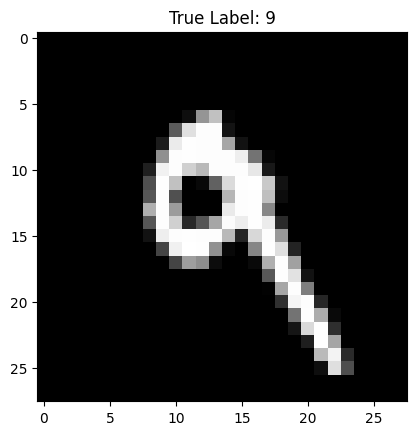

In [ ]:
import matplotlib.pyplot as plt

image, label = test_dataset[7]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.show()

In [ ]:
def train(model, num_epochs=10, lr=0.001):
  criterion = nn.CrossEntropyLoss()
  optimiser = torch.optim.Adam(model.parameters(), lr=lr)
  model.train()
  for epoch in tqdm(range(num_epochs)):
    for images, labels in train_loader:
      # Move tensors to the configured device
      images = images.to(device)
      labels = labels.to(device)

      # Forward pass
      outputs = model(images)
      loss = criterion(outputs, labels)

      # Backward pass and optimisation
      optimiser.zero_grad()
      loss.backward()
      optimiser.step()
    print(f' Loss: {loss.item():.4f}')

  5%|▌         | 1/20 [00:07<02:29,  7.87s/it]

Epoch [1/20], Loss: 1.5293


 10%|█         | 2/20 [00:15<02:16,  7.59s/it]

Epoch [2/20], Loss: 1.5256


 15%|█▌        | 3/20 [00:22<02:09,  7.63s/it]

...

Epoch [18/20], Loss: 1.4930


 95%|█████████▌| 19/20 [02:24<00:07,  7.58s/it]

Epoch [19/20], Loss: 1.4612


100%|██████████| 20/20 [02:32<00:00,  7.63s/it]

Epoch [20/20], Loss: 1.4612
